In [ ]:
# -*- coding: utf-8 -*-
#  Copyright 2025 United Kingdom Research and Innovation
#  Copyright 2025 The University of Manchester
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
# Authors:
# Evan Kiely (Warwick Manufacturing Group, University of Warwick)
# Hannah Robarts (STFC - UKRI)
# Laura Murgatroyd (UKRI-STFC)

# WaygateDataReader demo

The WaygateDataReader reads Waygate .pca data files and loads:
- Geometry data into the CIL geomeotry format
- Projection data which has already been normalised with flat and dark fields cast to float 32

The dataset is a CT scan of a plug collected by Evelien Zwanenburg and Jay Warnett at WMG on a Waygate Phoenix V|tome|x M300. The dataset can be downloaded from https://zenodo.org/records/14993754

This notebook was developed with CIL v25.0.0

In [2]:
import cil
cil.version.version

'26.0.0'

First import some relevant python libraries

In [3]:
import os
from readers.WaygateDataReader import WaygateDataReader

from cil.processors import CentreOfRotationCorrector, TransmissionAbsorptionConverter, Padder
from cil.utilities.display import show2D, show_geometry
from cil.utilities.jupyter import islicer
from cil.recon import FDK
from cil.io import TIFFStackReader

/home/lhe97136/miniconda3/envs/cil_26_demos/lib/python3.12/site-packages/cil/processors/CofR_image_sharpness.py:21: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  import scipy


Load the Waygate dataset

In [4]:
path = '/mnt/share/stfc.ac.uk/tomography/hackathon-11-25/waygate_plug/acq_data_750'
filename = os.path.join(path, 'Plug 750.pca')
data = WaygateDataReader(file_name = filename).read()

Visualise and print the geometry

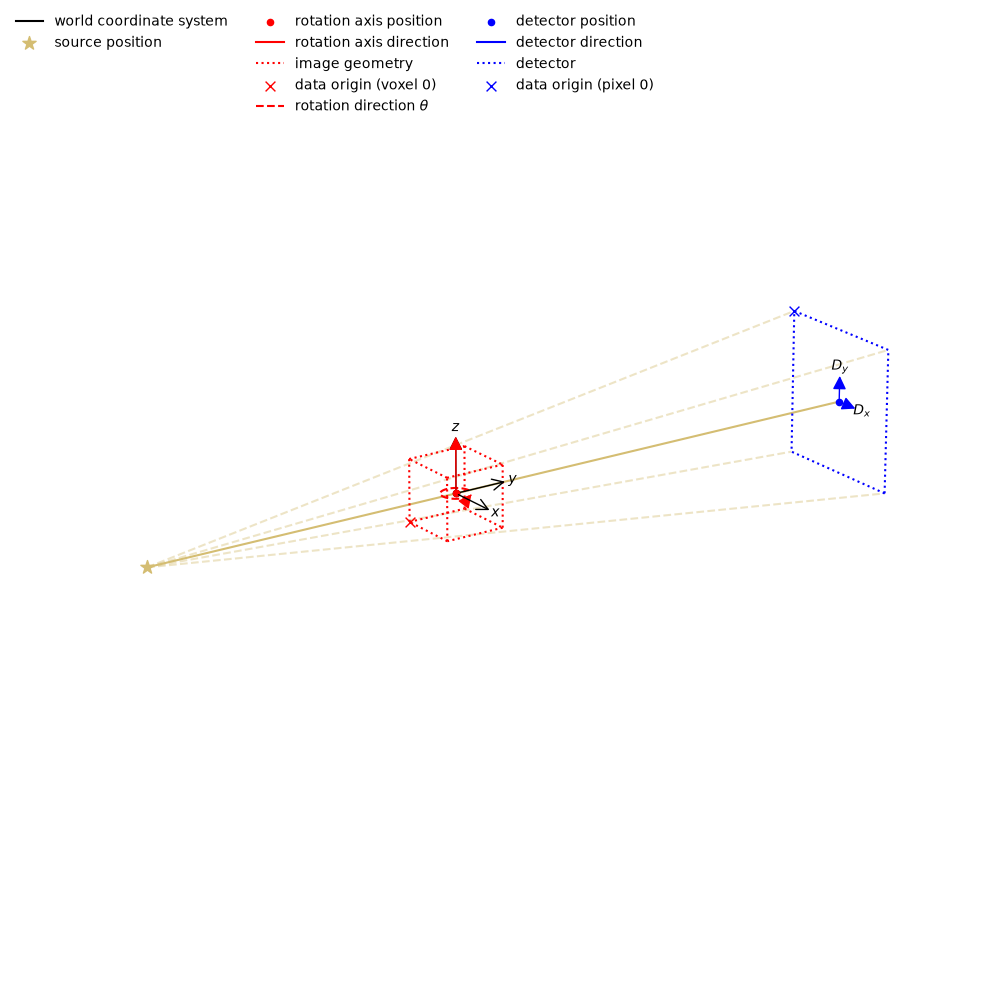

In [5]:
show_geometry(data.geometry)

In [6]:
print(data.geometry)

3D Cone-beam tomography
System configuration:
	Source position: [   0.        , -342.75938969,    0.        ]
	Rotation axis position: [-0.,  0.,  0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [  0.        , 463.73620931,   0.        ]
	Detector direction x: [1., 0., 0.]
	Detector direction y: [0., 0., 1.]
Panel configuration:
	Number of pixels: [750 750]
	Pixel size: [0.2 0.2]
	Pixel origin: top-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 1200
	Angles 0-9 in degrees: [ 0. , -0.3, -0.6, -0.9, -1.2, -1.5, -1.8, -2.1, -2.4, -2.7]
	Angles 1190-1199 in degrees: [-357. , -357.3, -357.6, -357.9, -358.2, -358.5, -358.8, -359.1, -359.4,
 -359.7]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: units distance


Scroll through the data using `islicer`

In [7]:
islicer(data)

The data is already normalised between 0-1, next we convert to absorption

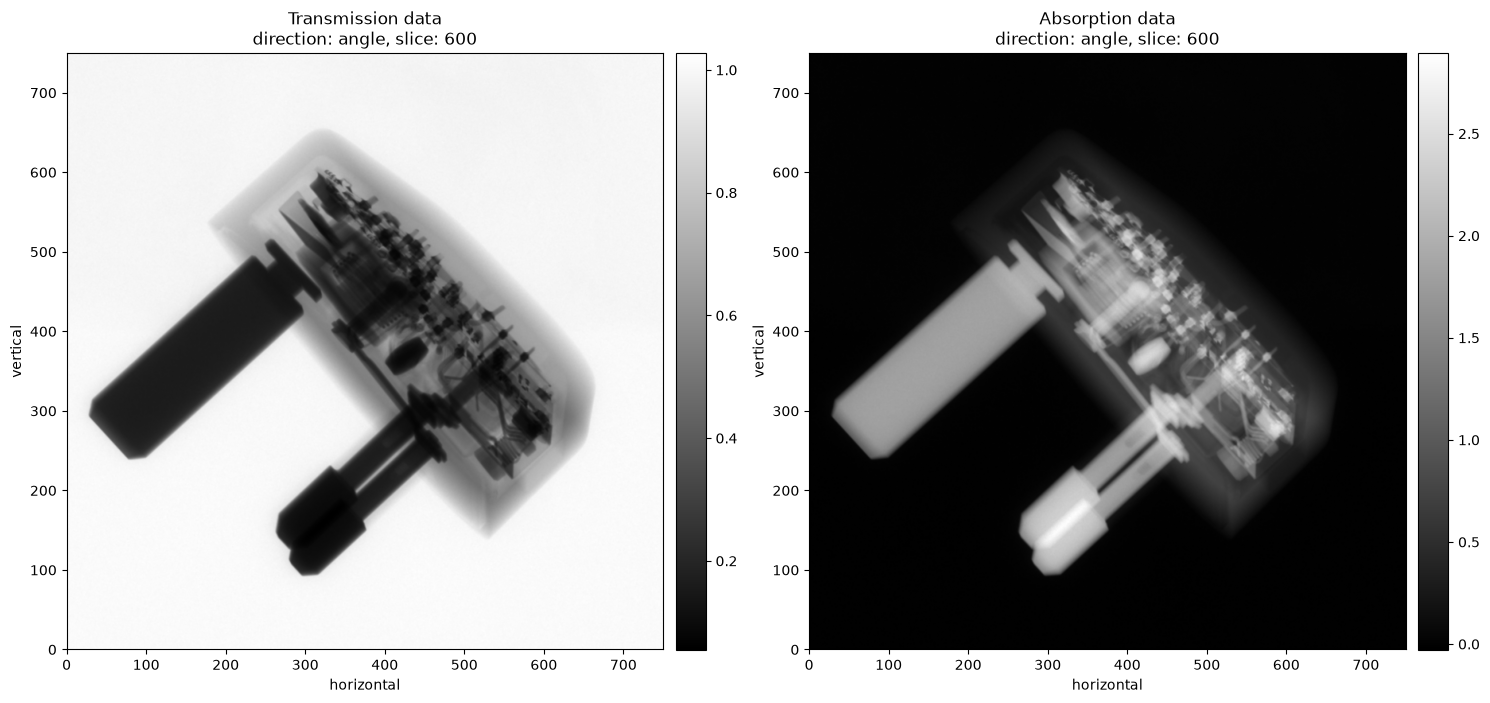

In [8]:
data_norm= TransmissionAbsorptionConverter()(data)
show2D([data, data_norm], ['Transmission data', 'Absorption data'])

Now we use FDK from the CIL recon class to reconstruct the data

In [9]:
fdk = FDK(data_norm)                                           
recon = fdk.run()

FDK recon

Input Data:
	angle: 1200
	vertical: 750
	horizontal: 750

Reconstruction Volume:
	vertical: 750
	horizontal_y: 750
	horizontal_x: 750

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False



Visualise the central slice of the reconstruction

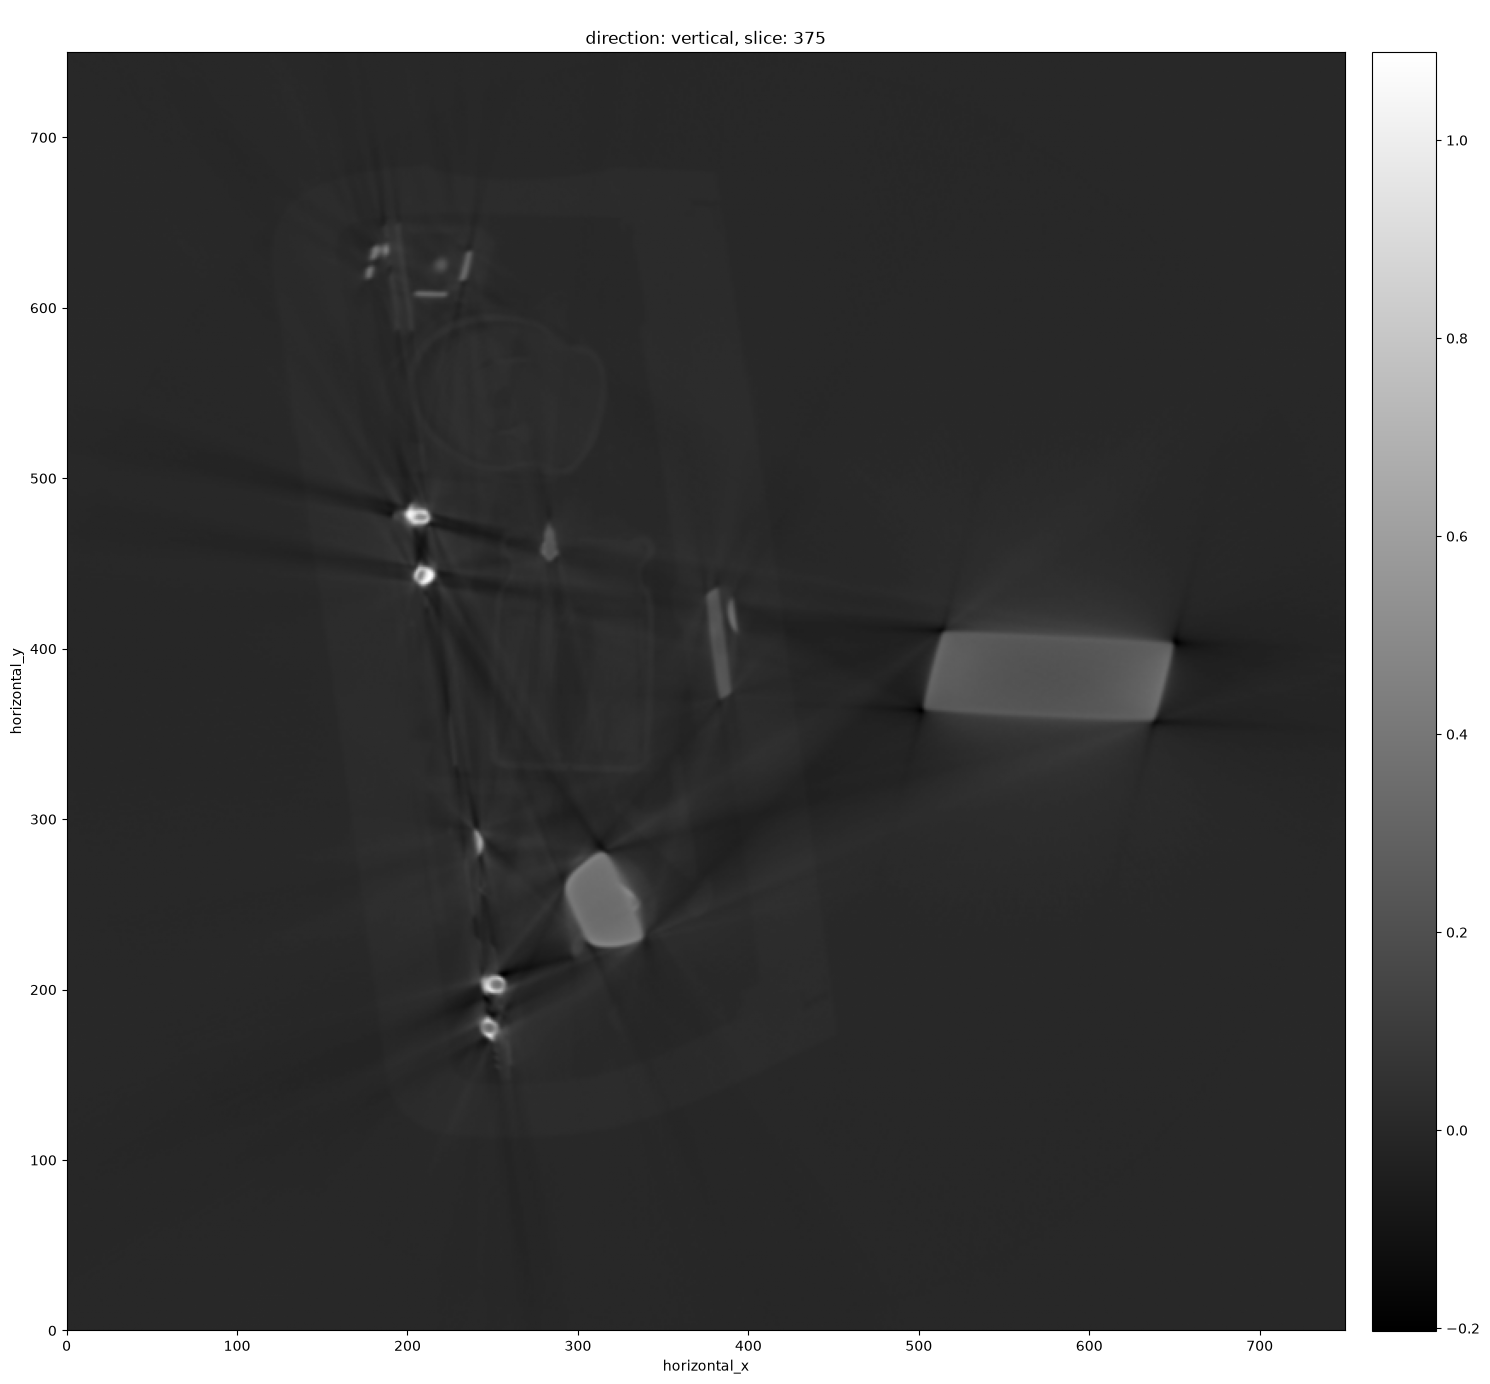

In [10]:
show2D(recon)

We notice a lot of artefacts in the reconstruction likely due to the metal parts of the plug. We can optimise the centre of rotation using the `CentreOfRotationCorrector.image_sharpness` method

In [11]:
print(f"Centre of rotation before = {data.geometry.get_centre_of_rotation(distance_units='pixels')}")
data_centred = CentreOfRotationCorrector.image_sharpness(backend='tigre')(data_norm)
print(f"Centre of rotation after = {data.geometry.get_centre_of_rotation(distance_units='pixels')}")

Centre of rotation before = {'offset': (np.float64(0.0), 'pixels'), 'angle': (0.0, 'radian')}
Centre of rotation after = {'offset': (np.float64(0.0), 'pixels'), 'angle': (0.0, 'radian')}


Re-run the reconstruction

In [12]:
fdk = FDK(data_centred)                                             
recon_centred = fdk.run()

FDK recon

Input Data:
	angle: 1200
	vertical: 750
	horizontal: 750

Reconstruction Volume:
	vertical: 750
	horizontal_y: 750
	horizontal_x: 750

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False



Zoom in on a small area to see if the image sharpness has improved

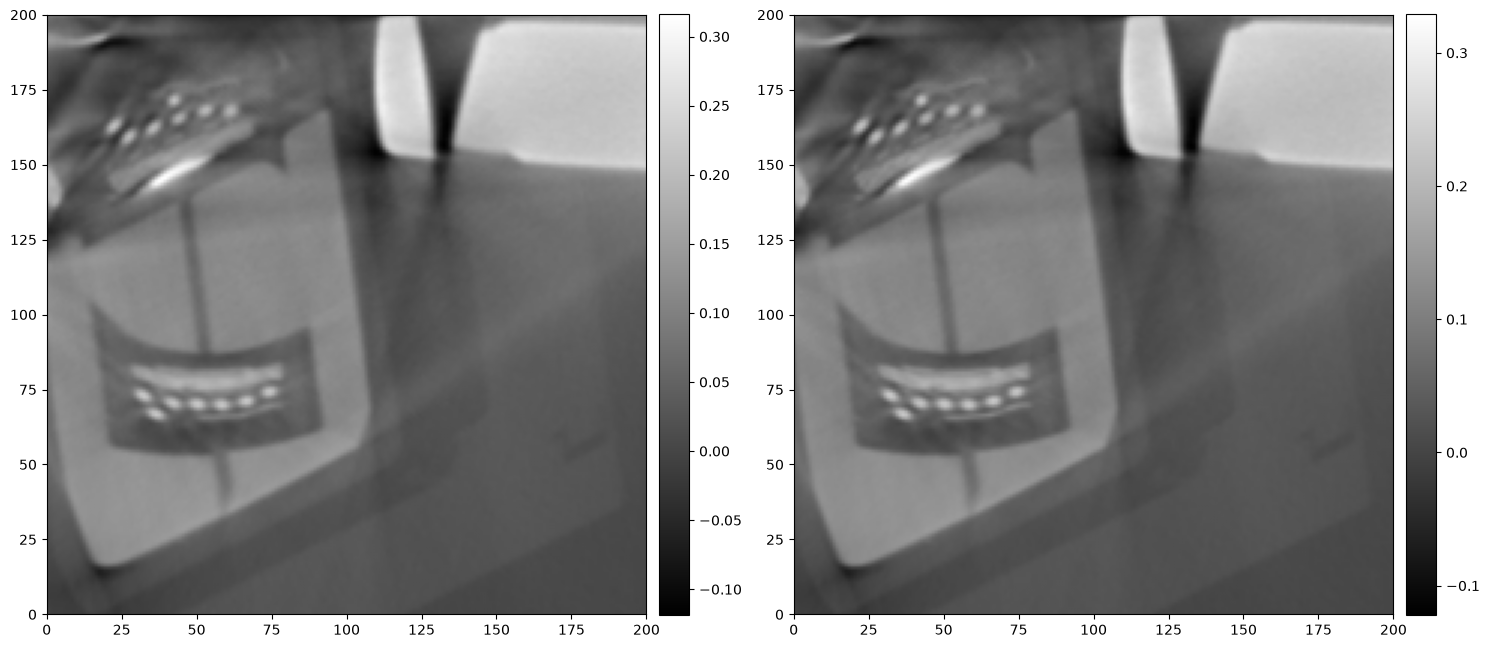

In [13]:
show2D([recon.array[300,200:400,320:520], recon_centred.array[300,200:400,320:520]])

Use `islicer` to scroll through the reconstruction, we can use the range sliders to zoom in on specific details 

In [14]:
islicer(recon_centred)

In [15]:
recon_filename = '/mnt/share/stfc.ac.uk/tomography/hackathon-11-25/waygate_plug/recon_750'
recon_waygate = TIFFStackReader(recon_filename).read()

Compare our reconstruction with the one provided by Waygate

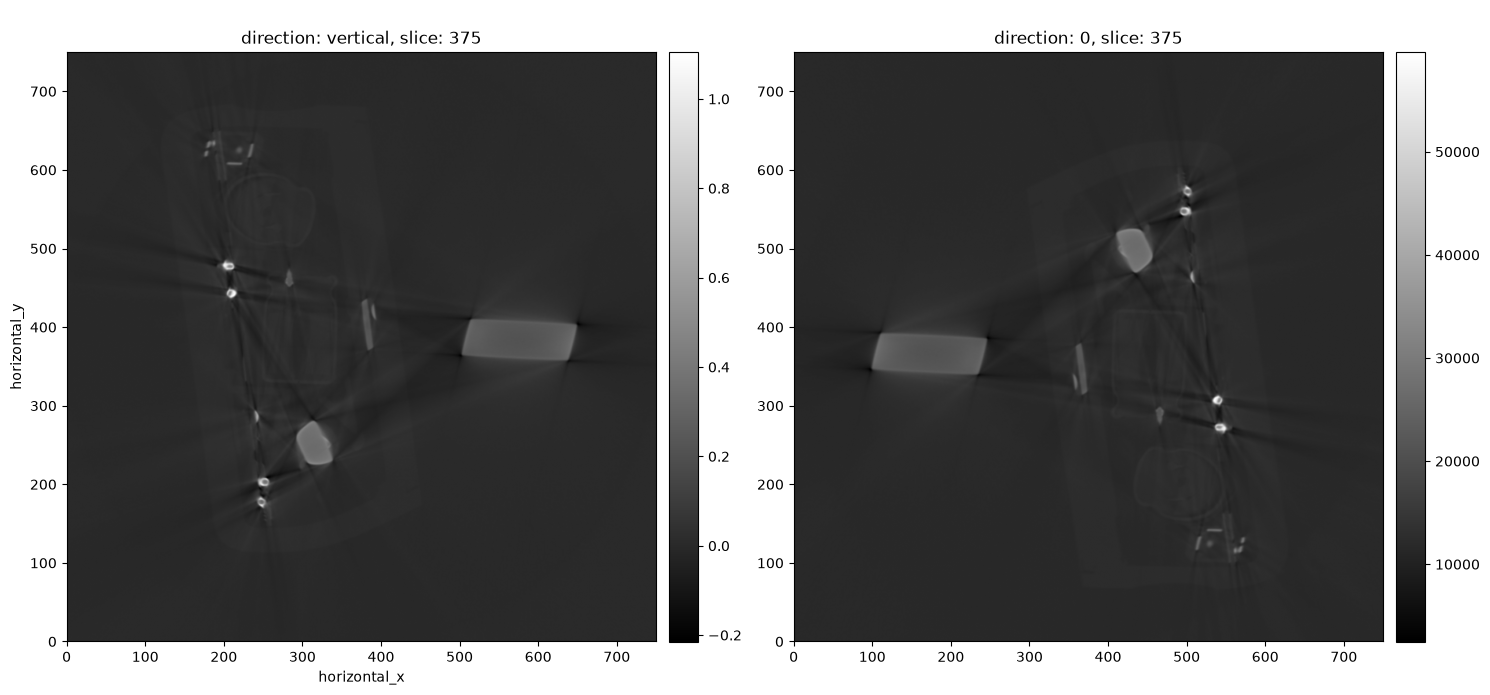

In [16]:
show2D([recon_centred, recon_waygate])

Now we test if we can load in only a subset of the data using the `roi` argument

First we select a smaller region around the plug by restricting the vertical range

Original shape = (1200, 750, 750)
ROI shape = (1200, 560, 750)


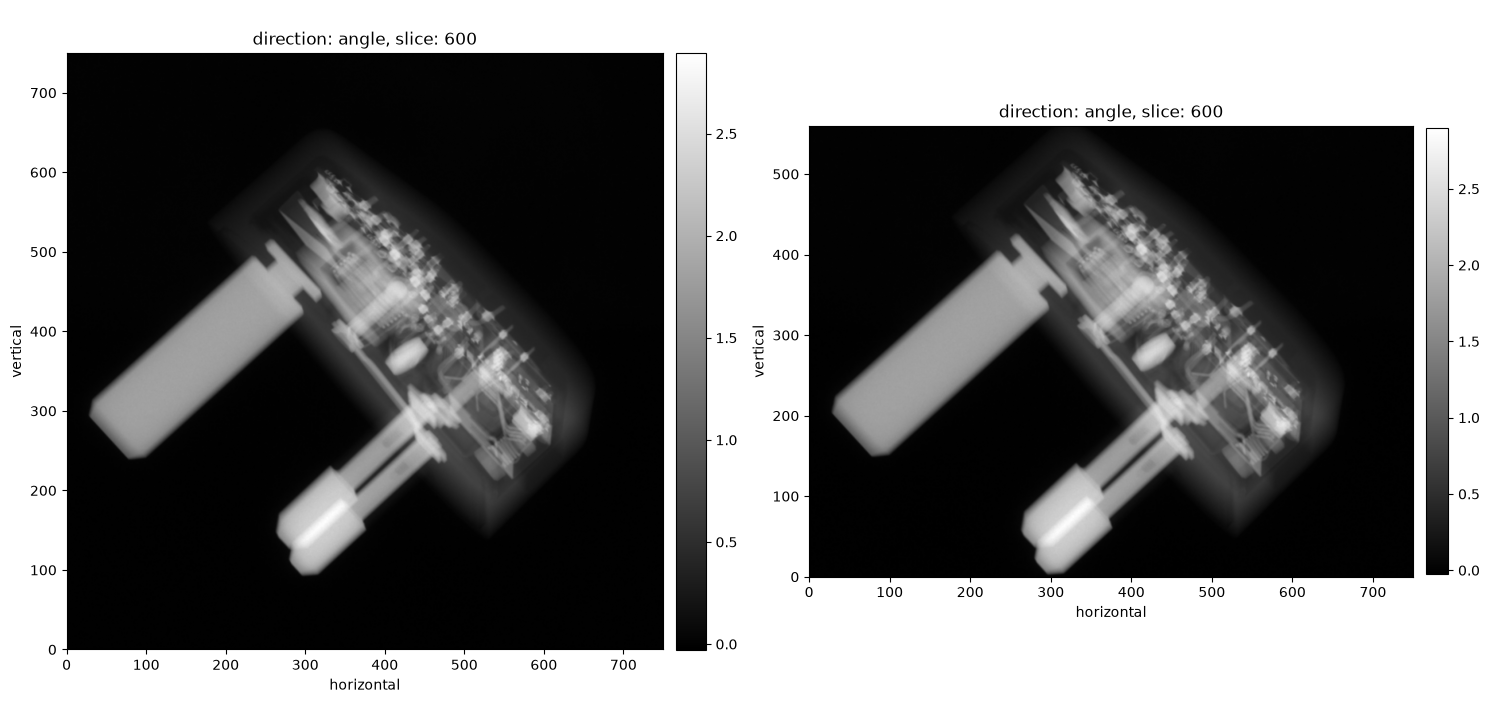

In [17]:
data_roi = WaygateDataReader(filename, roi={'vertical':(90, 650)}).read()
data_roi = TransmissionAbsorptionConverter()(data_roi)
print(f'Original shape = {data.shape}')
print(f'ROI shape = {data_roi.shape}')
show2D([data_norm, data_roi])

Next we try binning the data using `roi={'horizontal':(0,-1,10), 'vertical':(0,-1,10)}` to specify the full range in vertical and horizontal but binned 10x.

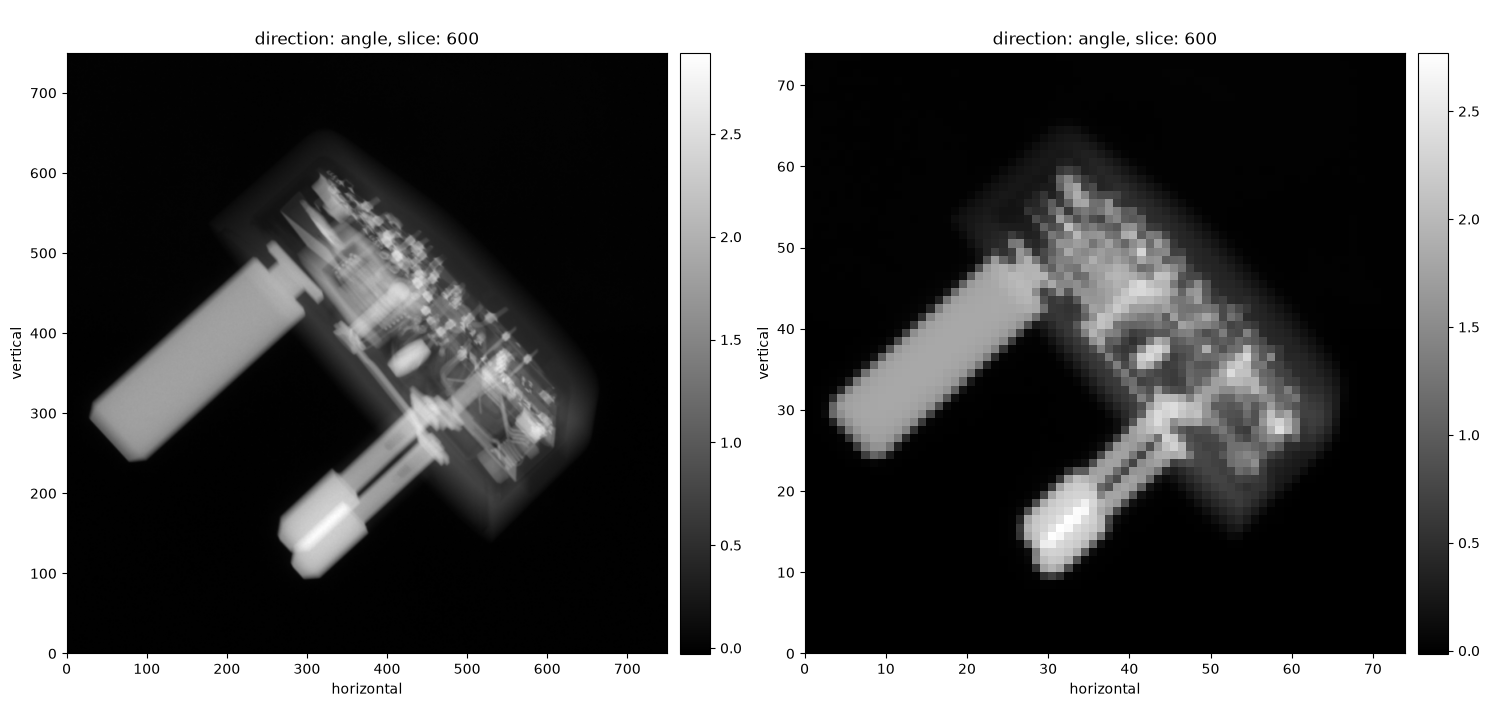

In [18]:
data_binned = WaygateDataReader(filename, roi={'horizontal':(0,-1,10), 'vertical':(0,-1,10)}).read()
data_binned = TransmissionAbsorptionConverter()(data_binned)
show2D([data_norm, data_binned])

Try reducing the number of angles loaded using `roi={'angle' : (0, -1, 3)}` and specifying `mode='slice'` to read only every 3rd projection. Here we visualise the ROI by looking at the sinogram.

Original shape = (1200, 750, 750)
ROI shape = (400, 750, 750)


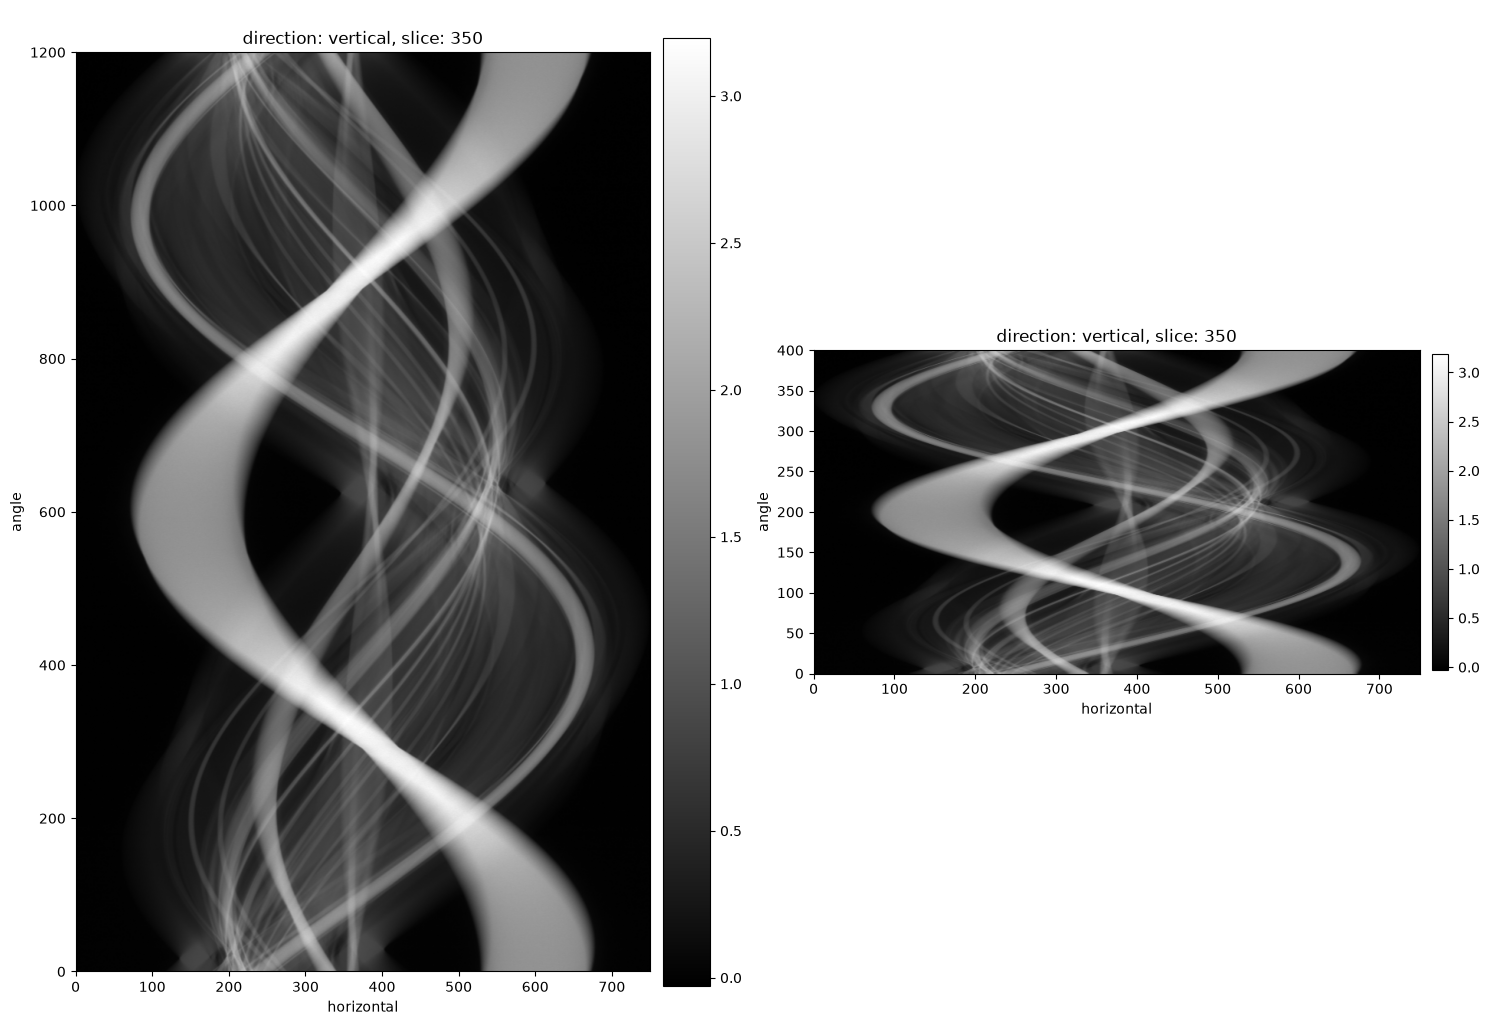

In [19]:
data_sliced = WaygateDataReader(filename, roi={'angle' : (0, -1, 3)}, mode='slice').read()
data_sliced = TransmissionAbsorptionConverter()(data_sliced)
print(f'Original shape = {data.shape}')
print(f'ROI shape = {data_sliced.shape}')
show2D([data_norm, data_sliced], slice_list = ('vertical', 350))

Try reconstructing the sliced data

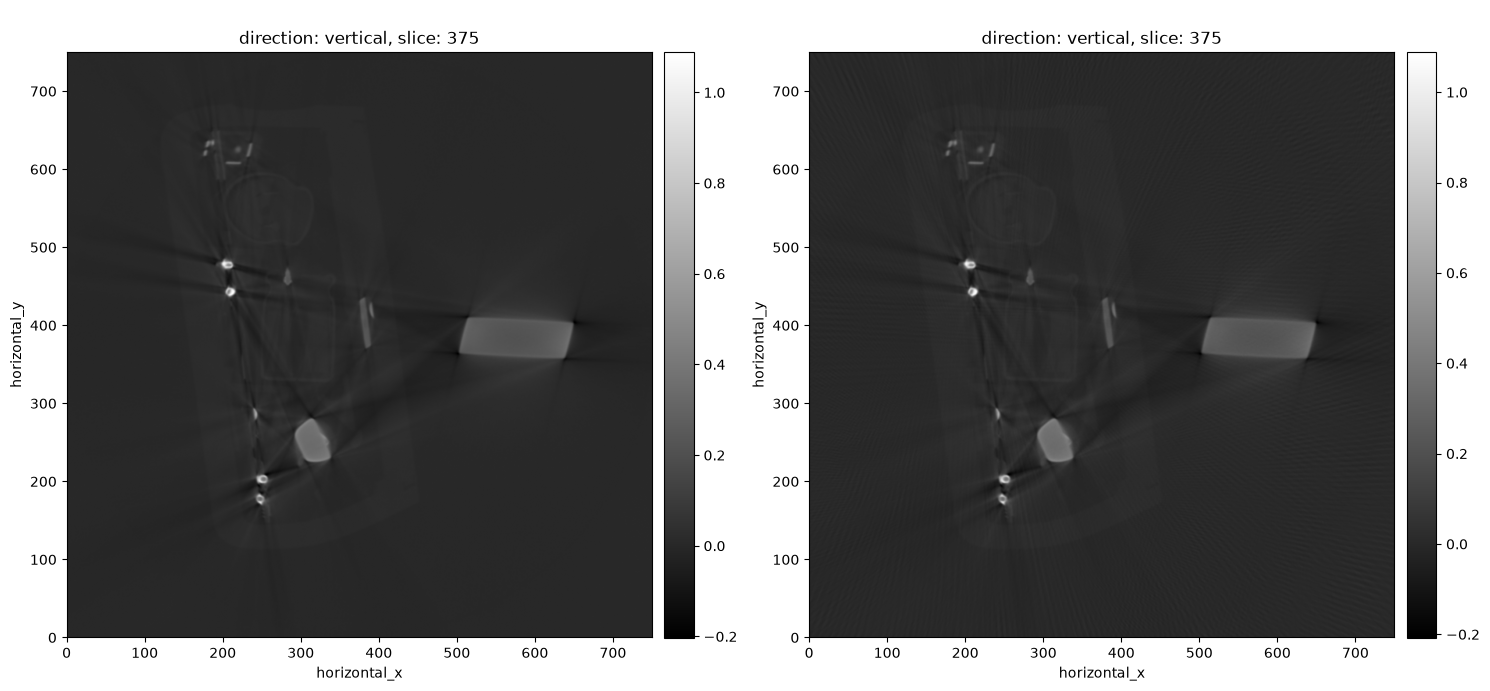

In [20]:
fdk = FDK(data_sliced)                                             
recon_sliced = fdk.run(verbose=False)
show2D([recon, recon_sliced])

Next we use `fliplr=True` to test changing the origin of the dataset

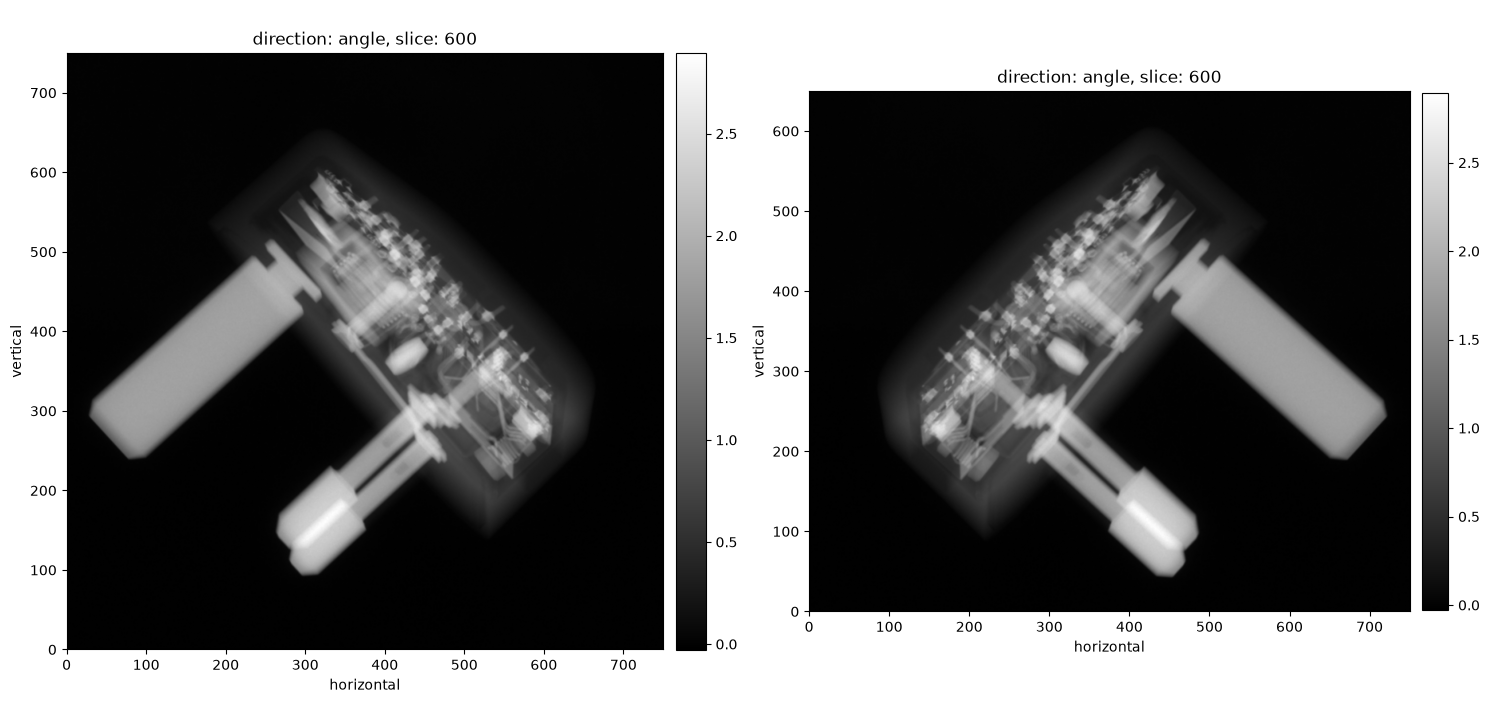

In [21]:
data_flip = WaygateDataReader(filename, roi={'vertical':(50, 700)}, fliplr=True).read()
data_flip= TransmissionAbsorptionConverter()(data_flip)
show2D([data_norm, data_flip])

And also check there is no impact on the reconstruction

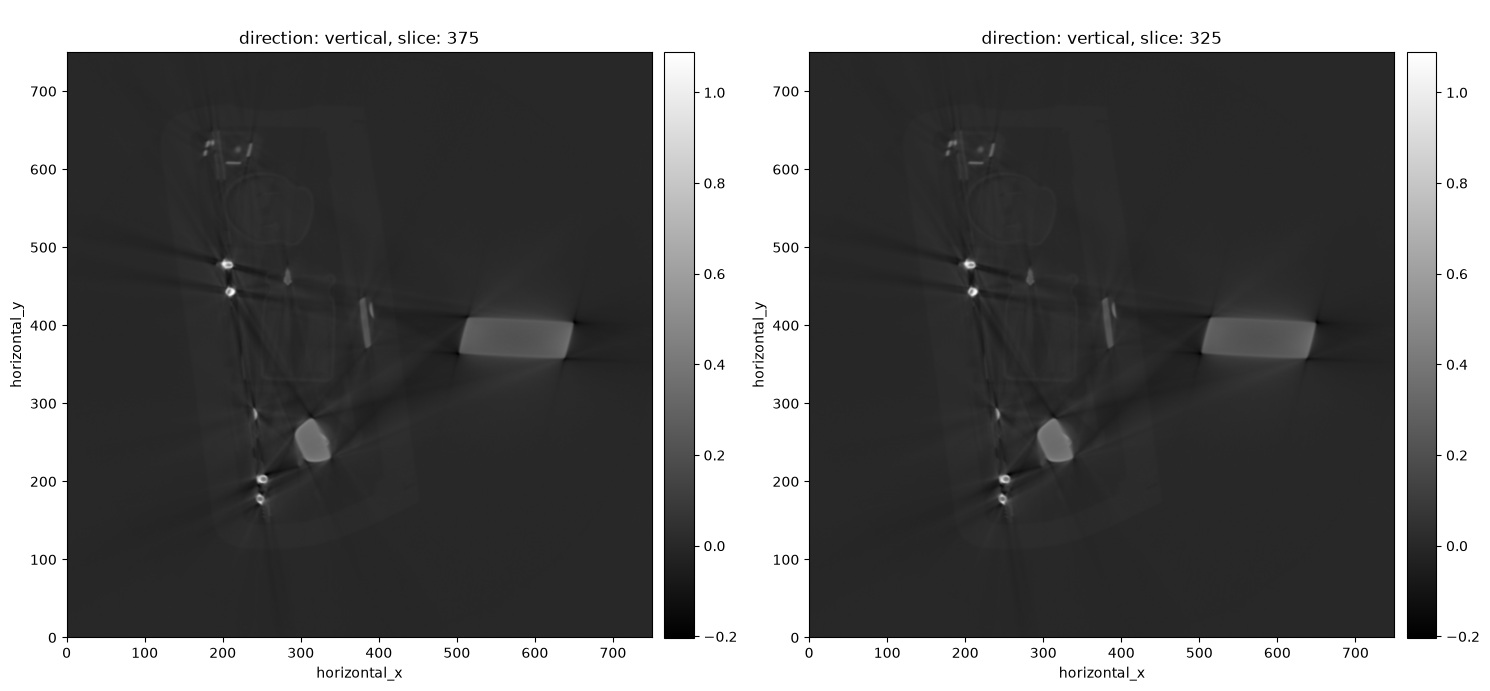

In [22]:
fdk = FDK(data_flip)                                             
recon_flip = fdk.run(verbose=False)
show2D([recon, recon_flip])